#  Data Cleanser: Data Preprocessing and Feature Engineering

## Import Libraries

In [111]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats
from scipy.stats.mstats import winsorize


In [112]:
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [114]:

# Load Dataset
df = pd.read_csv('patient_health_dataset.csv')

df.head()


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,58.0,Female,East,27.854327,120.967116,262.222480,123.045038,1
1,2,71.0,NaN,East,26.080083,90.368002,172.418462,NaN,0
2,3,48.0,Male,East,27.092170,105.909969,124.091374,110.502362,0
3,4,34.0,Female,East,28.737909,117.838687,191.419873,NaN,0
4,5,62.0,NaN,South,48.602403,101.854579,466.057578,302.827178,1


## Dataset Information

In [116]:

# Basic Info
print("Shape:", df.shape)
df.info()


Shape: (600, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      600 non-null    int64  
 1   age             570 non-null    float64
 2   gender          570 non-null    object 
 3   region          570 non-null    object 
 4   bmi             570 non-null    float64
 5   blood_pressure  600 non-null    float64
 6   cholesterol     570 non-null    float64
 7   glucose         570 non-null    float64
 8   disease_risk    600 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 42.3+ KB


## Missing Value Analysis

In [118]:

# Missing Value Summary
missing_summary = df.isnull().sum()
missing_percentage = (df.isnull().sum()/len(df))*100

summary = pd.DataFrame({
    "Missing Values": missing_summary,
    "Percentage": missing_percentage
})

summary


,Missing Values,Percentage
patient_id,0,0.0
age,30,5.0
gender,30,5.0
region,30,5.0
bmi,30,5.0
blood_pressure,0,0.0
cholesterol,30,5.0
glucose,30,5.0
disease_risk,0,0.0


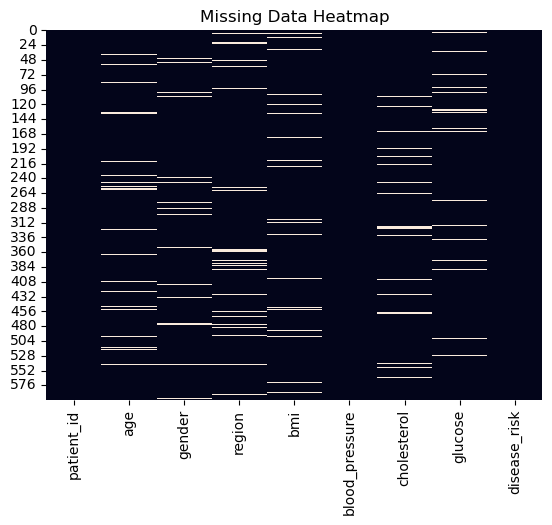

In [119]:

# Visualize Missing Data
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()


## Missing Indicator Columns

In [121]:

df['age_missing'] = df['age'].isnull().astype(int)
df['bmi_missing'] = df['bmi'].isnull().astype(int)
df['cholesterol_missing'] = df['cholesterol'].isnull().astype(int)
df['glucose_missing'] = df['glucose'].isnull().astype(int)


## Simple Imputer (Mean/Most Frequent)

In [123]:

df_simple = df.copy()

num_cols = ['age','bmi','cholesterol','glucose']
cat_cols = ['gender','region']

mean_imputer = SimpleImputer(strategy='mean')
mode_imputer = SimpleImputer(strategy='most_frequent')

df_simple[num_cols] = mean_imputer.fit_transform(df_simple[num_cols])
df_simple[cat_cols] = mode_imputer.fit_transform(df_simple[cat_cols])


## KNN Imputer

In [125]:

df_knn = df.copy()

knn = KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn.fit_transform(df_knn[num_cols])


## MICE (Iterative Imputer)

In [127]:

df_mice = df.copy()

mice = IterativeImputer(random_state=0)
df_mice[num_cols] = mice.fit_transform(df_mice[num_cols])


## Outlier Detection

In [129]:

numeric_cols = ['bmi','blood_pressure','cholesterol','glucose']

# Z-score
z_scores = np.abs(stats.zscore(df_simple[numeric_cols]))
outliers_z = (z_scores > 3)

print("Z-score outliers:")
print(np.sum(outliers_z))

Z-score outliers:
bmi               13
blood_pressure     1
cholesterol       15
glucose           11
dtype: int64


## IQR Method

In [131]:

df_iqr = df_simple.copy()

for col in numeric_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_iqr[col] = np.where(df_iqr[col] < lower, lower, df_iqr[col])
    df_iqr[col] = np.where(df_iqr[col] > upper, upper, df_iqr[col])


## Percentile Capping

In [133]:

df_percentile = df_iqr.copy()

for col in numeric_cols:
    lower = df_percentile[col].quantile(0.01)
    upper = df_percentile[col].quantile(0.99)

    df_percentile[col] = np.clip(df_percentile[col], lower, upper)


## Winsorization

In [135]:

df_final = df_percentile.copy()

for col in numeric_cols:
    df_final[col] = winsorize(df_final[col], limits=[0.01,0.01])


## Before vs After Comparison

In [137]:

print("Before Cleaning")
print(df.describe())

print("\nAfter Cleaning")
print(df_final.describe())


Before Cleaning
       patient_id         age         bmi  blood_pressure  cholesterol  \
count  600.000000  570.000000  570.000000      600.000000   570.000000   
mean   300.500000   50.487719   28.405783      120.678437   206.953447   
std    173.349358   17.590859    6.864749       14.878331    48.477243   
min      1.000000   20.000000   12.518723       76.179743   109.414635   
25%    150.750000   36.000000   24.233765      110.820958   180.755433   
50%    300.500000   51.000000   27.911826      120.251534   201.081354   
75%    450.250000   66.000000   31.251113      130.882582   221.408358   
max    600.000000   79.000000   69.007598      167.896614   508.260887   

          glucose  disease_risk  age_missing  bmi_missing  \
count  570.000000    600.000000   600.000000   600.000000   
mean   103.187266      0.440000     0.050000     0.050000   
std     32.553055      0.496801     0.218127     0.218127   
min     29.196110      0.000000     0.000000     0.000000   
25%     84.3

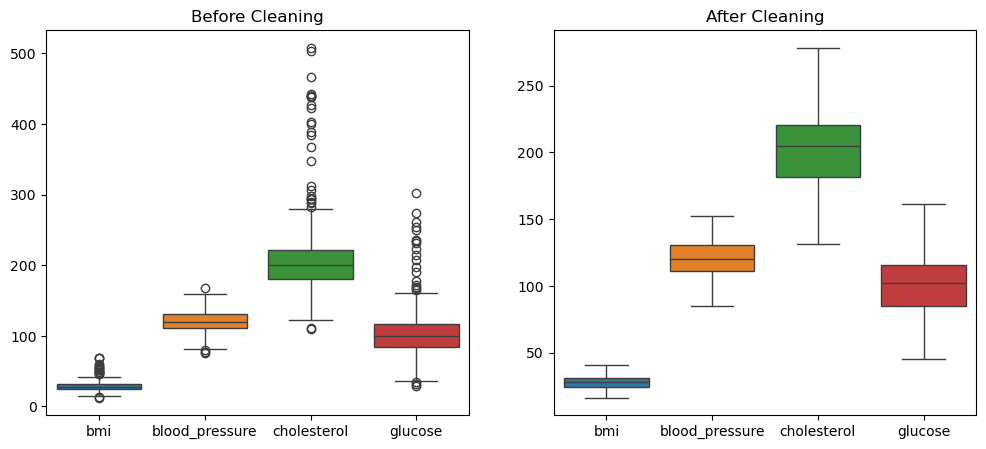

In [138]:

# Boxplot comparison

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=df[numeric_cols])
plt.title("Before Cleaning")

plt.subplot(1,2,2)
sns.boxplot(data=df_final[numeric_cols])
plt.title("After Cleaning")

plt.show()


## Save Final Clean Dataset

In [140]:

df_final.to_csv("clean_patient_dataset.csv", index=False)
print("Clean dataset saved successfully.")


Clean dataset saved successfully.
